# 1. Постановка задачи

* Дан датасет с параметрами домов House Prices
* Задача провести анализ и построить модель, которая предсказывает цену дома
# 2. Подгружаем необходимые библиотеки

In [1]:
# Загружаем библиотеки
import os
import numpy as np
import pandas as pd
import seaborn as sns

# Визуализация
import matplotlib.pyplot as plt

# ML / sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.linear_model import Ridge

# Models
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

# Feature engineering
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))
from src.features import FeatureEngineer, feature_engineering

# 3. Загрузим данные в датасеты

In [2]:
train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

# 4. Делаем EDA & Data Preprocessing

In [3]:
train.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## Заполняем пропуски - Nan

Посмотрим количество пропусков в наших данных

In [4]:
missing = train.isnull().sum()
missing[missing > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

Из файла [data_description.txt](../data/raw/data_description.txt) проанализируем описания полей

Избавляемся от пропусков:
* LotFrontage      259 - Это линейная часть улицы прилегающая к территории, можно заменить на медиану
* Alley           1369 - NA это "No alley access", можно заменить на 0
* MasVnrType       872 - Тип каменной укладки, заменяем на 0
* MasVnrArea         8 - площадь укладки, заменяем на медиану по группировке с MasVnrType
* BsmtQual          37 - NA означает "No Basement", заменяем на 0
* BsmtCond          37 - NA означает "No Basement", заменяем на 0
* BsmtExposure      38 - NA означает "No Basement", заменяем на 0
* BsmtFinType1      37 - NA означает "No Basement", заменяем на 0
* BsmtFinType2      38 - NA означает "No Basement", заменяем на 0
* Electrical         1 - Электричество, ставим моду
* FireplaceQu      690 - NA означает "No Fireplace", ставим 0
* GarageType        81 - NA означает "No Garage", ставим 0
* GarageYrBlt       81 - NA означает "No Garage", ставим 0
* GarageFinish      81 - NA означает "No Garage", ставим 0
* GarageQual        81 - NA означает "No Garage", ставим 0
* GarageCond        81 - NA означает "No Garage", ставим 0
* PoolQC          1453 - NA означает "No Pool", ставим 0
* Fence           1179 - NA означает "No Fence", ставим 0
* MiscFeature     1406 - NA означает "None", ставим 0

In [5]:
# Копируем train, чтобы не портить оригинал
train_df = train.copy()

# 1. LotFrontage — медиана по району
train_df["LotFrontage"] = train_df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# 2. Alley: NA = No alley access
train_df["Alley"] = train_df["Alley"].fillna("None")

# 3. MasVnrType / MasVnrArea
train_df["MasVnrType"] = train_df["MasVnrType"].fillna("None")
train_df["MasVnrArea"] = train_df["MasVnrArea"].fillna(train_df["MasVnrArea"].median())

# 4. Basement
for col in ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]:
    train_df[col] = train_df[col].fillna("None")

# 5. Electrical ставим моду
train_df["Electrical"] = train_df["Electrical"].fillna(train_df["Electrical"].mode()[0])

# 6. Fireplace
train_df["FireplaceQu"] = train_df["FireplaceQu"].fillna("None")

# 7. Garage
for col in ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]:
    train_df[col] = train_df[col].fillna("None")
train_df["GarageYrBlt"] = train_df["GarageYrBlt"].fillna(0)

# 8. Pool / Fence / MiscFeature
train_df["PoolQC"] = train_df["PoolQC"].fillna("None")
train_df["Fence"] = train_df["Fence"].fillna("None")
train_df["MiscFeature"] = train_df["MiscFeature"].fillna("None")


In [6]:
# Копируем test, чтобы не портить оригинал
test_df = test.copy()

# 1. LotFrontage — медиана по району
test_df["LotFrontage"] = test_df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# 2. Alley: NA = No alley access
test_df["Alley"] = test_df["Alley"].fillna("None")

# 3. MasVnrType / MasVnrArea
test_df["MasVnrType"] = test_df["MasVnrType"].fillna("None")
test_df["MasVnrArea"] = test_df["MasVnrArea"].fillna(test_df["MasVnrArea"].median())

# 4. Basement
for col in ["BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2"]:
    test_df[col] = test_df[col].fillna("None")

# 5. Electrical ставим моду
test_df["Electrical"] = test_df["Electrical"].fillna(test_df["Electrical"].mode()[0])

# 6. Fireplace
test_df["FireplaceQu"] = test_df["FireplaceQu"].fillna("None")

# 7. Garage
for col in ["GarageType","GarageFinish","GarageQual","GarageCond"]:
    test_df[col] = test_df[col].fillna("None")
test_df["GarageYrBlt"] = test_df["GarageYrBlt"].fillna(0)

# 8. Pool / Fence / MiscFeature
test_df["PoolQC"] = test_df["PoolQC"].fillna("None")
test_df["Fence"] = test_df["Fence"].fillna("None")
test_df["MiscFeature"] = test_df["MiscFeature"].fillna("None")

## Проанализируем признаки

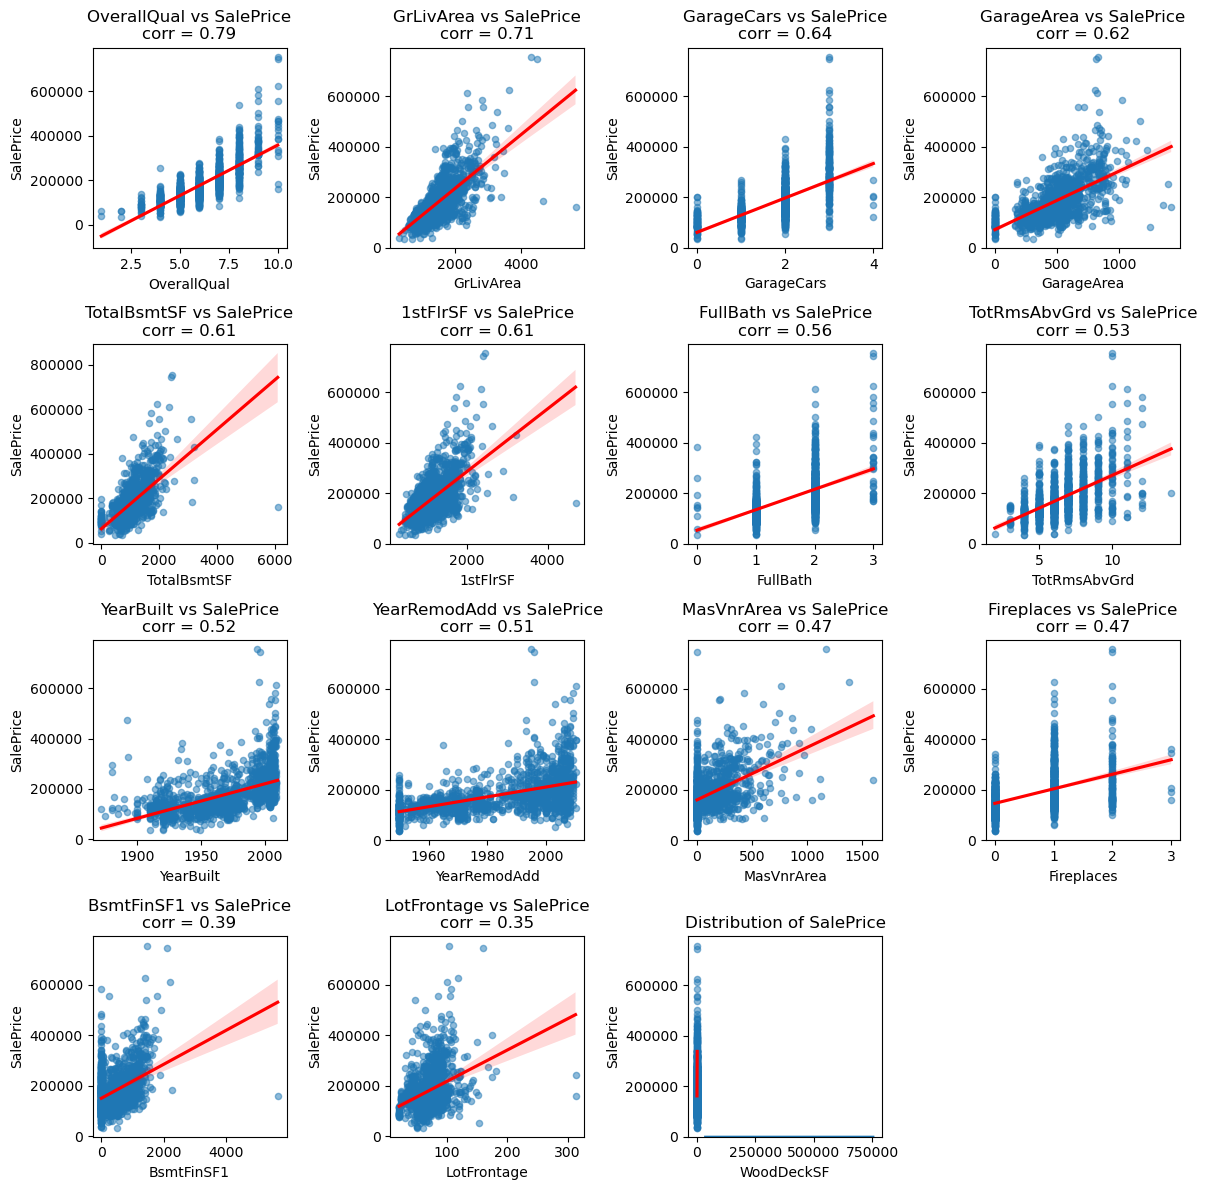

In [7]:
# Выбор числовых признаков, которые хотим сравнить с ценой
numeric_features = train_df.select_dtypes(include=["int64", "float64"]).columns
numeric_features = numeric_features.drop("SalePrice")

# Считаем корреляции с целевой переменной
corr_with_target = (
    train_df[numeric_features]
    .corrwith(train_df["SalePrice"])
    .abs()
    .sort_values(ascending=False)
)

top_numeric_features = corr_with_target.head(15).index.tolist()

# Строим корреляционную матрицу только для топ-признаков
top_corr_matrix = train_df[top_numeric_features].corr()

# Визуализация
n_cols = 4
n_rows = int(np.ceil(len(top_numeric_features) / n_cols))

plt.figure(figsize=(12, 12))

for i, col in enumerate(top_numeric_features, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.regplot(
        data=train_df,
        x=col,
        y="SalePrice",
        scatter_kws={"alpha": 0.5, "s": 20},
        line_kws={"color": "red"}
    )

    plt.title(f"{col} vs SalePrice\ncorr = {corr_with_target[col]:.2f}")

plt.tight_layout()

# проверяем распределение таргета
sns.histplot(train_df["SalePrice"], kde=True)
plt.title("Distribution of SalePrice")
plt.show()

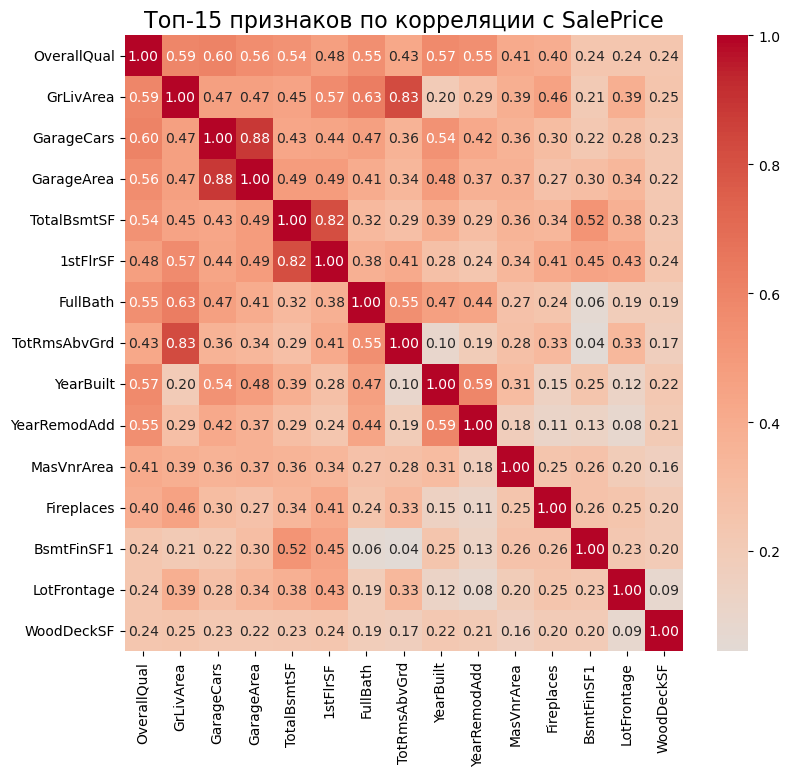

In [8]:
# Строим heatmap только для этих признаков
plt.figure(figsize=(9, 8))
sns.heatmap(
    top_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Топ-15 признаков по корреляции с SalePrice", fontsize=16)
plt.show()

# 5. Построим модели


## OneHotEncoder

In [9]:
# Настройка OneHotEncoder
ohe_kwargs = dict(handle_unknown="ignore")
try:
    OneHotEncoder(sparse_output=False)
    ohe_kwargs["sparse_output"] = False
except TypeError:
    ohe_kwargs["sparse"] = False

## RMSE scorer

In [10]:
rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)

## Разделим данные на тренировочные и тестовые

In [11]:
# Разделяем на признаки и целевую переменную
X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

## Сделаем пайплайны моделей Ridge и XGB
Подготовим параметры пайплайна для наших данных

In [12]:
# Подготовим данные
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]),
         selector(dtype_include=np.number)),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(**ohe_kwargs))
        ]), selector(dtype_exclude=np.number)),
    ],
    remainder="drop"
)

In [13]:
ridge_pipe = Pipeline([
    ("feat", FeatureEngineer()),
    ("prep", preprocessor),
    ("model", Ridge(alpha=10))
])

In [14]:
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_pipe = Pipeline([
    ("feat", FeatureEngineer()),
    ("prep", preprocessor),
    ("model", xgb_model),
])

### Сравним эффективности моделей через Cross-validation

In [15]:
models_rmse = dict()

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [("Ridge", ridge_pipe), ("XGBoost", xgb_pipe)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring=rmse_scorer, n_jobs=-1)
    print(f"{name} RMSE (CV mean): {-scores.mean():.4f}  | std: {scores.std():.4f}")
    models_rmse[name] = round(-scores.mean(), 4)

Ridge RMSE (CV mean): 32683.0720  | std: 11706.1313
XGBoost RMSE (CV mean): 27815.6617  | std: 8145.0017


## Сделаем модель CatBoost

In [17]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cat_rmse = []

In [18]:
for tr_idx, val_idx in cv.split(X):
    X_tr = X.iloc[tr_idx].copy()
    X_val = X.iloc[val_idx].copy()
    y_tr = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    # Feature engineering внутри фолда
    X_tr = feature_engineering(X_tr)
    X_val = feature_engineering(X_val)

    # cat_features как имена колонок
    cat_cols = X_tr.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    # приводим к строкам
    for c in cat_cols:
        X_tr[c] = X_tr[c].astype(str)
        X_val[c] = X_val[c].astype(str)

    catboost = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        early_stopping_rounds=200
    )

    catboost.fit(
        X_tr, y_tr,
        cat_features=cat_cols,
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    preds = catboost.predict(X_val)
    cat_rmse.append(np.sqrt(mean_squared_error(y_val, preds)))

In [19]:
print(f"CatBoost RMSE (CV mean): {np.mean(cat_rmse):.4f} | std: {np.std(cat_rmse):.4f}")
models_rmse['CatBoost'] = round(np.mean(cat_rmse), 4)

CatBoost RMSE (CV mean): 25997.7470 | std: 5974.0573


### Имеем в итоге:

In [20]:
for name, rmse in models_rmse.items():
    print(name, rmse)
    
# Минимальное ЗНАЧЕНИЕ
min_val = min(models_rmse.values())

# Лучшая МОДЕЛЬ
best_model = min(models_rmse, key=models_rmse.get)

print(f'Лучшая модель: {best_model} {round(min_val, 4)}')

Ridge 32683.072
XGBoost 27815.6617
CatBoost 25997.747
Лучшая модель: CatBoost 25997.747


# 6. Submission

In [21]:

# 1) Feature engineering на train/test (те же преобразования, что и при валидации)
train_fe = feature_engineering(train_df)
test_fe  = feature_engineering(test_df)

X_train_full = train_fe.drop("SalePrice", axis=1)
y_train_full = train_fe["SalePrice"]
X_test = test_fe.copy()

# 2) Список категориальных колонок определяем по train
cat_cols = X_train_full.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

# приводим категории к строкам и в train, и в test
for c in cat_cols:
    X_train_full[c] = X_train_full[c].astype(str)
    X_test[c] = X_test[c].astype(str)

# 3) Финальная модель (параметры такие же, как в CV-эксперименте)
final_catboost = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

# 4) Обучаем на всём train
final_catboost.fit(
    X_train_full, y_train_full,
    cat_features=cat_cols
)

# 5) Предсказываем для test и формируем submission
test_pred = final_catboost.predict(X_test)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_pred
})

submission["SalePrice"] = submission["SalePrice"].clip(lower=0)

# 6) Сохраняем
out_dir = Path("..") / "submissions"
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / "submission_catboost.csv"
submission.to_csv(out_path, index=False)

print("Saved submission to:", out_path)
submission.head()


Saved submission to: ../submissions/submission_catboost.csv


,Id,SalePrice
0,1461,119705.073935
1,1462,159740.428325
2,1463,189246.009453
3,1464,196885.930348
4,1465,181848.428467


Exception ignored in: <function ResourceTracker.__del__ at 0x105339c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105ac1c60>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105471c60>
Traceback (most recent call last